# Identifying Underutilised Districts for Crop Production

**Goal:** Districts that are absent from the training data (no historical crop records) but whose **climate features** make them climatically similar to districts that the models classify as **high-yield**. These are the underutilised districts that policy can prioritise.

**Approach:**
1. Load all trained models (KNN, Random Forest, XGBoost) per crop.
2. Load the full climate feature dataset — this covers *all* districts, not just those with crop history.
3. Identify the "unseen" districts: present in climate data but absent from the crop classified files.
4. Run ensemble prediction across all three models for each unseen district × crop combination.
5. Flag districts predicted as **High** yield by a majority (≥ 2/3) of models.
6. Produce a ranked policy report and supporting visualisations.

In [36]:
import os
import glob
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
os.makedirs("underutilised_districts", exist_ok=True)

print("Libraries loaded.")

Libraries loaded.


## 1 — Configuration

In [37]:
CLASSIFIED_DIR = "clean_crop_contribution_data/aggregated_data/kmeans_classes"
FEATURES_FILE  = "engineered_climate_features_correlation_analyzed.csv"
MIN_ROWS       = 200          # same gate used during training
N_SPLITS       = 5            # same CV splits used during training
HIGH_CLASS     = "High"       # the yield class label we care about
MAJORITY_VOTE  = 2            # minimum number of models that must agree (out of 3)
TOP_N_REPORT   = 30           # districts to highlight in the summary table

# Drop columns used during training (must match exactly)
DROP_COLS = ["State", "District", "location", "Median", "Max", "Yield_Class"]

print("Configuration set.")

Configuration set.


## 1b — Urban District Exclusions

**Why this exists:** The climate feature file contains only meteorological and soil moisture signals (rainfall, evaporation, soil water volume, temperature, etc.) — there is no land-use variable. This means the OOD filter cannot distinguish a fully urbanised district like Delhi or Hyderabad from a nearby agricultural district that shares an identical climate profile. Both look the same to the model.

**Approach:** Rather than silently dropping results, we maintain an explicit exclusion list of known metro/urban districts where agricultural land is negligible. This list is intentionally small and conservative — only districts where the district *itself* is the city, not peri-urban districts that still have meaningful farmland (e.g. Faridabad, Gurugram are kept).

**Known limitation:** This is a manual patch for a data gap. The correct long-term fix is to include a net-sown-area or NDVI-based land-use feature in the climate dataset, which would let the OOD filter handle this automatically.

In [38]:
# Districts excluded because their climate profile is indistinguishable from
# neighbouring agricultural zones, but they have negligible agricultural land.
# Only hard metro-core districts are listed — not peri-urban districts with real farmland.
URBAN_EXCLUSIONS = {
    # Delhi — all sub-districts are urban; agriculture is negligible
    "Delhi_North", "Delhi_North West", "Delhi_South West", "Delhi_West",
    "Delhi_South", "Delhi_South East", "Delhi_Central", "Delhi_New Delhi",
    "Delhi_North East", "Delhi_East",

    # Major metros where the district itself is the city
    "Telangana_Hyderabad",
    "West Bengal_Kolkata",
    "Tamil Nadu_Chennai",
    "Rajasthan_Phalodi",
    "Chandigarh_Chandigarh",
    "Uttar Pradesh_Lucknow",
    "Maharashtra_Mumbai Suburban",

}

print(f"Urban exclusion list: {len(URBAN_EXCLUSIONS)} districts")
print("These will be removed from the unseen candidate pool before prediction.")

Urban exclusion list: 17 districts
These will be removed from the unseen candidate pool before prediction.


## 2 — Load the Full Climate Feature Dataset

This file covers **all** districts, not just those with crop data. Every row is one `State_District` location.

In [39]:
features_df = pd.read_csv(FEATURES_FILE)

# Confirm the location key exists
assert "location" in features_df.columns, (
    "'location' column not found in features file. "
    "Expected format: State_District (e.g. 'Maharashtra_Pune')."
)

print(f"Climate features loaded: {features_df.shape[0]:,} districts, {features_df.shape[1]} columns")
print("Sample locations:")
print(features_df["location"].head(10).tolist())

Climate features loaded: 773 districts, 37 columns
Sample locations:
['A & N Islands_Nicobars', 'A & N Islands_North And Middle Andaman', 'A & N Islands_South Andamans', 'Andhra Pradesh_Alluri Sitharama Raju', 'Andhra Pradesh_Anakapalli', 'Andhra Pradesh_Anantapur', 'Andhra Pradesh_Annamayya', 'Andhra Pradesh_Bapatla', 'Andhra Pradesh_Chittoor', 'Andhra Pradesh_East Godavari']


## 3 — Enumerate Available Crops and Identify Unseen Districts

For each crop we determine:
- **Seen districts** — locations present in the classified CSV (used in training/evaluation).
- **Unseen districts** — locations in the full climate dataset but absent from the crop's classified file. These are candidates.

In [40]:
csv_files = glob.glob(os.path.join(CLASSIFIED_DIR, "*_classified.csv"))
print(f"Found {len(csv_files)} classified crop files.\n")

all_climate_locations = set(features_df["location"].unique())
print(f"Total districts in climate data: {len(all_climate_locations):,}")

crop_meta = {}   # crop_name -> {seen, unseen, class_df}

for csv_path in sorted(csv_files):
    crop_name = os.path.basename(csv_path).replace("_classified.csv", "")
    class_df  = pd.read_csv(csv_path)

    # Apply the same row-count gate used during training
    if len(class_df) <= MIN_ROWS:
        print(f"  [SKIP] {crop_name} — only {len(class_df)} rows (need > {MIN_ROWS})")
        continue

    class_df["location"] = class_df["State"] + "_" + class_df["District"]
    seen_locations   = set(class_df["location"].unique())
    unseen_locations = all_climate_locations - seen_locations
    # Remove known urban districts — climate features have no land-use signal
    # so the model cannot distinguish these from nearby agricultural zones.
    unseen_locations = unseen_locations - URBAN_EXCLUSIONS

    crop_meta[crop_name] = {
        "seen":     seen_locations,
        "unseen":   unseen_locations,
        "class_df": class_df,
    }
    print(f"  {crop_name:<30}  seen={len(seen_locations):>4}  unseen={len(unseen_locations):>4}  (after urban exclusion)")

print(f"\nCrops eligible for analysis: {len(crop_meta)}")

Found 54 classified crop files.

Total districts in climate data: 773
  [SKIP] arecanut — only 152 rows (need > 200)
  arhar_tur                       seen= 667  unseen=  94  (after urban exclusion)
  bajra                           seen= 504  unseen= 259  (after urban exclusion)
  banana                          seen= 407  unseen= 355  (after urban exclusion)
  barley                          seen= 329  unseen= 432  (after urban exclusion)
  [SKIP] black_pepper — only 123 rows (need > 200)
  [SKIP] cardamom — only 52 rows (need > 200)
  [SKIP] cashewnut — only 126 rows (need > 200)
  castorseed                      seen= 391  unseen= 368  (after urban exclusion)
  [SKIP] coconut — only 53 rows (need > 200)
  coriander                       seen= 407  unseen= 353  (after urban exclusion)
  cotton                          seen= 455  unseen= 305  (after urban exclusion)
  cowpea_lobia                    seen= 233  unseen= 527  (after urban exclusion)
  dry_chillies                    see

## 4 — Train Final Models on All Available Data

During the original notebooks, models were trained inside a cross-validation loop.  
Here we retrain **one final model per algorithm per crop** using the **entire seen dataset**, so we can apply it to the unseen districts.

This mirrors the standard train-on-all / predict-on-new workflow.

In [41]:
trained_models = {}   # crop_name -> {"knn": ..., "rf": ..., "xgb": ..., "scaler": ..., "le": ..., "feature_cols": ...}

for crop_name, meta in crop_meta.items():
    class_df = meta["class_df"]

    # Merge with climate features (inner join — same as training)
    merged_df = class_df.merge(features_df, on="location", how="inner")

    # Drop classes that are too rare (< N_SPLITS samples) — same gate as training
    class_counts = merged_df["Yield_Class"].value_counts()
    valid_classes = class_counts[class_counts >= N_SPLITS].index.tolist()
    merged_df = merged_df[merged_df["Yield_Class"].isin(valid_classes)].copy()

    if len(merged_df) <= MIN_ROWS or len(valid_classes) < 2:
        print(f"  [SKIP after filter] {crop_name}")
        continue

    # Encode target
    le = LabelEncoder()
    y  = pd.Series(le.fit_transform(merged_df["Yield_Class"]), index=merged_df.index)

    # Build feature matrix (drop same columns as in training)
    extra_drop = [c for c in DROP_COLS if c in merged_df.columns]
    X = merged_df.drop(columns=extra_drop + ["Yield_Class_Encoded"] if "Yield_Class_Encoded" in merged_df.columns else extra_drop)
    # Also drop the encoded column if it snuck through
    if "Yield_Class_Encoded" in X.columns:
        X = X.drop(columns=["Yield_Class_Encoded"])

    feature_cols = X.columns.tolist()
    n_classes    = len(le.classes_)

    # Scale (required for KNN; harmless for RF/XGB)
    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # ---- KNN ----
    knn = KNeighborsClassifier(n_neighbors=5, weights="distance", metric="minkowski")
    knn.fit(X_scaled, y)

    # ---- Random Forest ----
    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )
    rf.fit(X_scaled, y)

    # ---- XGBoost ----
    xgb = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        use_label_encoder=False,
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1,
    )
    xgb.fit(X_scaled, y)

    trained_models[crop_name] = {
        "knn":          knn,
        "rf":           rf,
        "xgb":          xgb,
        "scaler":       scaler,
        "le":           le,
        "feature_cols": feature_cols,
        "class_names":  le.classes_.tolist(),
        "n_rows_train": len(merged_df),
    }
    
    # Store scaled training matrix for OOD detection (Mahalanobis)
    trained_models[crop_name]["X_train_scaled"] = X_scaled
    print(f"  ✓ {crop_name:<30}  trained on {len(merged_df):,} rows  |  classes: {le.classes_.tolist()}")

print(f"\nModels trained for {len(trained_models)} crops.")

  ✓ arhar_tur                       trained on 665 rows  |  classes: ['High', 'Low', 'Medium']
  ✓ bajra                           trained on 501 rows  |  classes: ['High', 'Low', 'Medium']
  ✓ banana                          trained on 405 rows  |  classes: ['High', 'Low', 'Medium']
  ✓ barley                          trained on 328 rows  |  classes: ['High', 'Low', 'Medium']
  ✓ castorseed                      trained on 390 rows  |  classes: ['High', 'Low', 'Medium']
  ✓ coriander                       trained on 406 rows  |  classes: ['High', 'Low', 'Medium']
  ✓ cotton                          trained on 454 rows  |  classes: ['High', 'Low', 'Medium']
  ✓ cowpea_lobia                    trained on 231 rows  |  classes: ['High', 'Low', 'Medium']
  ✓ dry_chillies                    trained on 577 rows  |  classes: ['High', 'Low', 'Medium']
  ✓ garlic                          trained on 439 rows  |  classes: ['High', 'Low', 'Medium']
  ✓ ginger                          trained on 444

## 5 — Predict Yield Class for Unseen Districts

For every unseen district × crop pair, we run all three models and record:
- Each model's predicted class and the probability of the **High** class.
- The **accuracy-weighted ensemble probability** — each model's `p_high` is weighted by its `acc_mean` for that specific crop, then normalised so the three weights sum to 1.
- Whether the majority (≥ 2/3) of models predict **High**.

### 5a — Load CV accuracy summaries (used as ensemble weights)

In [42]:
# Expected columns include: crop, acc_mean  (plus f1_mean, acc_std, etc.)
# acc_mean for a crop is used as that model's weight in the ensemble for that crop.
CV_SUMMARY_PATHS = {
    "knn": "knn/all_crops_summary_knn.csv",
    "rf":  "random_forest/all_crops_summary_random_forest.csv",
    "xgb": "xgboost/all_crops_summary_xgboost.csv",
}

cv_perf = {}   # model_key -> DataFrame with crop + acc_mean + f1_mean etc.

for model_key, path in CV_SUMMARY_PATHS.items():
    if not os.path.exists(path):
        print(f"  [WARNING] CV summary not found for {model_key}: {path}")
        print(f"            Run the corresponding notebook first.")
        print(f"            {model_key} will get weight=0 in the ensemble (excluded).")
        cv_perf[model_key] = pd.DataFrame(columns=["crop", "acc_mean", "acc_std", "f1_mean", "f1_std"])
    else:
        df = pd.read_csv(path)[["crop", "acc_mean", "acc_std", "f1_mean", "f1_std"]]
        cv_perf[model_key] = df.set_index("crop")
        print(f"  ✓ {model_key:<5}  loaded from {path}  ({len(df)} crops)")

def get_acc(model_key, crop_name):
    """Return acc_mean for a model×crop pair, or 0.0 if not available."""
    perf = cv_perf[model_key]
    if crop_name in perf.index:
        return float(perf.loc[crop_name, "acc_mean"])
    return 0.0

print("\nCV summaries ready — will be used as per-crop ensemble weights.")

  ✓ knn    loaded from knn/all_crops_summary_knn.csv  (43 crops)
  ✓ rf     loaded from random_forest/all_crops_summary_random_forest.csv  (43 crops)
  ✓ xgb    loaded from xgboost/all_crops_summary_xgboost.csv  (43 crops)

CV summaries ready — will be used as per-crop ensemble weights.


### 5b — Run predictions

In [43]:
results = []   # list of dicts, one per (district, crop) pair

for crop_name, models in trained_models.items():
    unseen_locations = crop_meta[crop_name]["unseen"]
    if not unseen_locations:
        print(f"  {crop_name}: no unseen districts — skipping.")
        continue

    feature_cols = models["feature_cols"]
    le           = models["le"]
    class_names  = models["class_names"]
    scaler       = models["scaler"]

    # Determine the encoded integer label for the High class (if it exists)
    has_high_class = HIGH_CLASS in class_names
    if not has_high_class:
        # Fall back to the highest ordinal class
        high_label_idx = len(class_names) - 1
        high_label_name = class_names[high_label_idx]
        print(f"  [{crop_name}] No '{HIGH_CLASS}' class found — using '{high_label_name}' as proxy.")
    else:
        high_label_idx  = list(class_names).index(HIGH_CLASS)
        high_label_name = HIGH_CLASS

    # Build the feature matrix for unseen districts
    unseen_df = features_df[features_df["location"].isin(unseen_locations)].copy()

    # Keep only the columns the model was trained on; fill missing with 0
    for col in feature_cols:
        if col not in unseen_df.columns:
            unseen_df[col] = 0.0
    X_unseen = unseen_df[feature_cols].fillna(0)
    X_unseen_scaled = scaler.transform(X_unseen)

    # --- Predictions ---
    knn_pred  = models["knn"].predict(X_unseen_scaled)
    rf_pred   = models["rf"].predict(X_unseen_scaled)
    xgb_pred  = models["xgb"].predict(X_unseen_scaled)

    knn_proba = models["knn"].predict_proba(X_unseen_scaled)[:, high_label_idx]
    rf_proba  = models["rf"].predict_proba(X_unseen_scaled)[:, high_label_idx]
    xgb_proba = models["xgb"].predict_proba(X_unseen_scaled)[:, high_label_idx]

    # Accuracy-weighted ensemble: each model's p_high is weighted by its acc_mean
    # for this specific crop, then normalised so weights sum to 1.
    # If a model's summary CSV is missing, its weight is 0 (excluded from ensemble).
    w_knn = get_acc("knn", crop_name)
    w_rf  = get_acc("rf",  crop_name)
    w_xgb = get_acc("xgb", crop_name)
    w_sum = w_knn + w_rf + w_xgb
    if w_sum == 0:
        # Fallback to equal weights if no accuracy info available for this crop
        w_knn = w_rf = w_xgb = 1.0
        w_sum = 3.0
    ensemble_proba = (w_knn * knn_proba + w_rf * rf_proba + w_xgb * xgb_proba) / w_sum

    for i, loc in enumerate(unseen_df["location"].values):
        state, district = loc.split("_", 1) if "_" in loc else (loc, loc)

        votes = sum([
            int(knn_pred[i])  == high_label_idx,
            int(rf_pred[i])   == high_label_idx,
            int(xgb_pred[i])  == high_label_idx,
        ])

        # OOD distance and flag — filled in by section 5c post-processing
        ood_dist = None
        ood_flag = None

        results.append({
            "crop":              crop_name,
            "location":          loc,
            "state":             state,
            "district":          district,
            "knn_pred_class":    class_names[int(knn_pred[i])],
            "rf_pred_class":     class_names[int(rf_pred[i])],
            "xgb_pred_class":    class_names[int(xgb_pred[i])],
            "knn_high_proba":    round(float(knn_proba[i]), 4),
            "rf_high_proba":     round(float(rf_proba[i]), 4),
            "xgb_high_proba":    round(float(xgb_proba[i]), 4),
            "knn_weight":        round(w_knn / w_sum, 4),
            "rf_weight":         round(w_rf  / w_sum, 4),
            "xgb_weight":        round(w_xgb / w_sum, 4),
            "ensemble_high_proba": round(float(ensemble_proba[i]), 4),
            "votes_for_high":    votes,
            "majority_high":     votes == 3 and float(ensemble_proba[i]) >= 0.9,
            "high_class_used":   high_label_name,
            "ood_distance":      ood_dist,
            "ood_flag":          ood_flag,
        })

    n_high = sum(1 for r in results if r["crop"] == crop_name and r["majority_high"])
    print(f"  {crop_name:<30}  unseen={len(unseen_df):>4}  unanimous+conf≥0.9={n_high:>4}")

results_df = pd.DataFrame(results)
print(f"\nTotal (district, crop) pairs evaluated: {len(results_df):,}")
print(f"Pairs — unanimous + ensemble ≥ 0.9:    {results_df['majority_high'].sum():,}")

  arhar_tur                       unseen=  94  unanimous+conf≥0.9=   4
  bajra                           unseen= 259  unanimous+conf≥0.9=   8
  banana                          unseen= 355  unanimous+conf≥0.9=  35
  barley                          unseen= 432  unanimous+conf≥0.9=  21
  castorseed                      unseen= 368  unanimous+conf≥0.9=   0
  coriander                       unseen= 353  unanimous+conf≥0.9=  52
  cotton                          unseen= 305  unanimous+conf≥0.9=  18
  cowpea_lobia                    unseen= 527  unanimous+conf≥0.9=   2
  dry_chillies                    unseen= 183  unanimous+conf≥0.9=   4
  garlic                          unseen= 320  unanimous+conf≥0.9=  23
  ginger                          unseen= 314  unanimous+conf≥0.9=  27
  gram                            unseen= 120  unanimous+conf≥0.9=   4
  [groundnut] No 'High' class found — using 'Medium' as proxy.
  groundnut                       unseen= 176  unanimous+conf≥0.9=   5
  horse_gram  

### 5c — OOD Filter: Mahalanobis Distance

For each unseen district × crop pair, compute how far the district sits from the **training distribution** in scaled feature space using Mahalanobis distance — which accounts for feature correlations and scale. Pairs beyond the **95th percentile** of training-sample distances are flagged as out-of-distribution (OOD): the model is extrapolating, so confident predictions on them (like Barmer for sugarcane) are unreliable and should not influence policy.

`majority_high` is recomputed here to add the OOD exclusion on top of the unanimous + ≥0.9 filters.

In [44]:
from scipy.spatial.distance import mahalanobis
from scipy.linalg import inv

OOD_PERCENTILE = 95   # districts within this percentile of training = in-distribution

ood_info = {}

for crop_name, models in trained_models.items():
    X_train = models["X_train_scaled"]          # scaled training matrix

    mu  = X_train.mean(axis=0)
    cov = np.cov(X_train, rowvar=False)
    cov_reg = cov + np.eye(cov.shape[0]) * 1e-6  # regularise to avoid singularity

    try:
        cov_inv = inv(cov_reg)
    except Exception:
        cov_inv = np.diag(1.0 / (np.diag(cov_reg) + 1e-6))

    # 95th-percentile distance among training points = threshold
    train_dists = np.array([mahalanobis(row, mu, cov_inv) for row in X_train])
    threshold   = np.percentile(train_dists, OOD_PERCENTILE)

    ood_info[crop_name] = {"mu": mu, "cov_inv": cov_inv, "threshold": threshold}

print(f"OOD thresholds set for {len(ood_info)} crops  (percentile={OOD_PERCENTILE})")
for cn, info in list(ood_info.items())[:5]:
    print(f"  {cn:<35}  threshold={info['threshold']:.3f}")

# ── Post-process results_df: fill ood_distance / ood_flag, recompute majority_high ──
print("\nComputing Mahalanobis distances for all unseen districts...")

ood_distances, ood_flags = [], []

for _, row in results_df.iterrows():
    crop_name = row["crop"]
    info      = ood_info.get(crop_name)
    if info is None:
        ood_distances.append(float("nan"))
        ood_flags.append(False)
        continue

    feature_cols = trained_models[crop_name]["feature_cols"]
    loc_row      = features_df[features_df["location"] == row["location"]][feature_cols]

    if loc_row.empty:
        ood_distances.append(float("nan"))
        ood_flags.append(True)    # can't verify → flag conservatively
        continue

    x    = loc_row.fillna(0).values[0]
    # Re-scale using the crop's scaler (features_df is unscaled)
    x_sc = trained_models[crop_name]["scaler"].transform(x.reshape(1, -1))[0]
    dist = mahalanobis(x_sc, info["mu"], info["cov_inv"])
    ood_distances.append(round(float(dist), 4))
    ood_flags.append(bool(dist > info["threshold"]))

results_df["ood_distance"] = ood_distances
results_df["ood_flag"]     = ood_flags

# Recompute majority_high with OOD exclusion
before = ((results_df["votes_for_high"] == 3) & (results_df["ensemble_high_proba"] >= 0.9))
results_df["majority_high"] = before & (~results_df["ood_flag"])

print(f"\nPassing unanimous + conf≥0.9            : {before.sum():>5,}")
print(f"Remaining after OOD exclusion           : {results_df['majority_high'].sum():>5,}")
print(f"Removed as out-of-distribution          : {(before & results_df['ood_flag']).sum():>5,}")
print(f"\nSample OOD-flagged pairs (check these):")
print(results_df[results_df["ood_flag"] & before][["crop","state","district","ensemble_high_proba","ood_distance"]].head(10).to_string(index=False))


OOD thresholds set for 43 crops  (percentile=95)
  arhar_tur                            threshold=8.847
  bajra                                threshold=9.629
  banana                               threshold=8.363
  barley                               threshold=10.020
  castorseed                           threshold=8.854

Computing Mahalanobis distances for all unseen districts...

Passing unanimous + conf≥0.9            :   907
Remaining after OOD exclusion           :   604
Removed as out-of-distribution          :   303

Sample OOD-flagged pairs (check these):
  crop      state        district  ensemble_high_proba  ood_distance
 bajra Tamil Nadu   Kanniyakumari               0.9468       10.7838
 bajra Tamil Nadu  Mayiladuthurai               0.9254       10.3516
banana    Gujarat Devbhumi Dwarka               0.9457       11.0910
banana    Gujarat       Porbandar               0.9355       14.5788
banana    Haryana          Ambala               0.9192        8.8646
banana    Hary

## 6 — Build the Per-Model Decision Table

Instead of collapsing to an ensemble vote, we produce a **long-form table** with one row per (district, crop, model) where that model predicted High.  
Each row is annotated with the **CV performance of that specific model on that crop** (accuracy and weighted F1 from the original training runs), so you can judge how much to trust each signal before making a policy call.

### 6a — CV performance summaries (already loaded in 5a, reused here)

In [45]:
# cv_perf was loaded in section 5a and is reused here for joining into the per-model table.
# Reset index so 'crop' is a column again for merging.
cv_perf_flat = {}
for model_key, df in cv_perf.items():
    reset = df.reset_index() if "crop" not in df.columns else df.copy()
    cv_perf_flat[model_key] = reset[["crop", "acc_mean", "acc_std", "f1_mean", "f1_std"]]
    print(f"  {model_key:<5}  {len(reset)} crops available")

print("\nReady to join into per-model table.")

  knn    43 crops available
  rf     43 crops available
  xgb    43 crops available

Ready to join into per-model table.


### 6b — Unpivot predictions into per-model rows and join CV stats

In [46]:
MODEL_PRED_COLS = {
    "knn": ("knn_pred_class", "knn_high_proba"),
    "rf":  ("rf_pred_class",  "rf_high_proba"),
    "xgb": ("xgb_pred_class", "xgb_high_proba"),
}

long_rows = []

for _, row in results_df.iterrows():
    for model_key, (pred_col, proba_col) in MODEL_PRED_COLS.items():
        predicted_class = row[pred_col]
        high_class_used = row["high_class_used"]

        # Only keep rows where THIS model predicted High
        if predicted_class != high_class_used:
            continue

        long_rows.append({
            "crop":            row["crop"],
            "state":           row["state"],
            "district":        row["district"],
            "location":        row["location"],
            "model":           model_key,
            "predicted_class": predicted_class,
            "p_high":          row[proba_col],
            "ensemble_p_high": row["ensemble_high_proba"],
            "votes_for_high":  row["votes_for_high"],
            "majority_high":   row["majority_high"],
        })

long_df = pd.DataFrame(long_rows)

# Join CV performance for each model
cv_frames = []
for model_key, perf_df in cv_perf_flat.items():
    subset = long_df[long_df["model"] == model_key].copy()
    merged = subset.merge(
        perf_df.rename(columns={
            "acc_mean": "cv_acc_mean",
            "acc_std":  "cv_acc_std",
            "f1_mean":  "cv_f1_mean",
            "f1_std":   "cv_f1_std",
        }),
        on="crop",
        how="left",
    )
    cv_frames.append(merged)

per_model_df = (
    pd.concat(cv_frames, ignore_index=True)
    .sort_values(["crop", "location", "model"])
    .reset_index(drop=True)
)

# Round for readability
for col in ["p_high", "ensemble_p_high", "cv_acc_mean", "cv_acc_std", "cv_f1_mean", "cv_f1_std"]:
    if col in per_model_df.columns:
        per_model_df[col] = per_model_df[col].round(4)

print(f"Total per-model High predictions: {len(per_model_df):,}")
print(f"  (each row = one model that predicted High for that district × crop)")
per_model_df.head(10)

Total per-model High predictions: 12,210
  (each row = one model that predicted High for that district × crop)


,crop,state,district,location,model,predicted_class,p_high,ensemble_p_high,votes_for_high,majority_high,cv_acc_mean,cv_acc_std,cv_f1_mean,cv_f1_std
0,arhar_tur,A & N Islands,Nicobars,A & N Islands_Nicobars,knn,High,0.6034,0.3189,1,False,0.6917,0.0218,0.6863,0.0199
1,arhar_tur,Arunachal Pradesh,Anjaw,Arunachal Pradesh_Anjaw,knn,High,0.5100,0.4560,2,False,0.6917,0.0218,0.6863,0.0199
2,arhar_tur,Arunachal Pradesh,Anjaw,Arunachal Pradesh_Anjaw,xgb,High,0.4532,0.4560,2,False,0.6992,0.0252,0.6978,0.0226
3,arhar_tur,Arunachal Pradesh,Itanagar Capital Complex,Arunachal Pradesh_Itanagar Capital Complex,knn,High,0.6224,0.5459,2,False,0.6917,0.0218,0.6863,0.0199
4,arhar_tur,Arunachal Pradesh,Itanagar Capital Complex,Arunachal Pradesh_Itanagar Capital Complex,xgb,High,0.5690,0.5459,2,False,0.6992,0.0252,0.6978,0.0226
5,arhar_tur,Arunachal Pradesh,Kra Daadi,Arunachal Pradesh_Kra Daadi,knn,High,0.5847,0.5823,3,False,0.6917,0.0218,0.6863,0.0199
6,arhar_tur,Arunachal Pradesh,Kra Daadi,Arunachal Pradesh_Kra Daadi,rf,High,0.5567,0.5823,3,False,0.5639,0.0202,0.5788,0.0219
7,arhar_tur,Arunachal Pradesh,Kra Daadi,Arunachal Pradesh_Kra Daadi,xgb,High,0.6008,0.5823,3,False,0.6992,0.0252,0.6978,0.0226
8,arhar_tur,Arunachal Pradesh,Kurung Kumey,Arunachal Pradesh_Kurung Kumey,knn,High,0.8512,0.8012,3,False,0.6917,0.0218,0.6863,0.0199
9,arhar_tur,Arunachal Pradesh,Kurung Kumey,Arunachal Pradesh_Kurung Kumey,rf,High,0.6200,0.8012,3,False,0.5639,0.0202,0.5788,0.0219


### 6c — Save the per-model decision table

This is the **primary output you review before making policy decisions.**  
- `cv_f1_mean` tells you how well this model did on this crop during training — low F1 = treat the prediction with more scepticism.  
- `votes_for_high` tells you how many of the other models agree.  
- `p_high` is this model's own confidence; `ensemble_p_high` is the average across all three.

In [47]:
per_model_df.to_csv("underutilised_districts/per_model_high_predictions.csv", index=False)
print("Saved → underutilised_districts/per_model_high_predictions.csv")
print("\nColumns:")
for col in per_model_df.columns:
    print(f"  {col}")

Saved → underutilised_districts/per_model_high_predictions.csv

Columns:
  crop
  state
  district
  location
  model
  predicted_class
  p_high
  ensemble_p_high
  votes_for_high
  majority_high
  cv_acc_mean
  cv_acc_std
  cv_f1_mean
  cv_f1_std


### 6d — Ensemble / district-level summary (kept for visualisations)

In [48]:
# high_df: pairs where ALL 3 models agree on High (or Medium for groundnut)
# AND ensemble_high_proba >= 0.9
high_df = (
    results_df[results_df["majority_high"]]
    .sort_values(["votes_for_high", "ensemble_high_proba"], ascending=False)
    .reset_index(drop=True)
)

# district_summary: one row per district, aggregated across crops
district_summary = (
    results_df
    .groupby(["state", "district", "location"])
    .agg(
        crops_evaluated     = ("crop", "count"),
        crops_high          = ("majority_high", "sum"),
        mean_ensemble_proba = ("ensemble_high_proba", "mean"),
        crops_high_list     = ("crop", lambda x: ", ".join(
            sorted(results_df.loc[
                x.index[results_df.loc[x.index, "majority_high"]], "crop"
            ].tolist())
        )),
    )
    .reset_index()
    .sort_values(["crops_high", "mean_ensemble_proba"], ascending=False)
    .reset_index(drop=True)
)
district_summary["pct_crops_high"] = (
    district_summary["crops_high"] / district_summary["crops_evaluated"] * 100
).round(1)

district_summary.to_csv("underutilised_districts/district_level_summary.csv", index=False)
results_df.to_csv("underutilised_districts/all_unseen_predictions.csv", index=False)

# ---- Primary output: all strict high-potential district-crop pairs ----
high_pairs_cols = [
    "crop", "state", "district", "location",
    "knn_pred_class", "rf_pred_class", "xgb_pred_class",
    "knn_high_proba", "rf_high_proba", "xgb_high_proba",
    "knn_weight", "rf_weight", "xgb_weight",
    "ensemble_high_proba", "votes_for_high", "high_class_used",
    "ood_distance",
    "ood_flag",
]
high_pairs_df = high_df[high_pairs_cols].copy()
high_pairs_df.to_csv("underutilised_districts/high_potential_pairs.csv", index=False)

print(f"Strict high-potential pairs : {len(high_pairs_df):,}")
print(f"Unique districts            : {high_pairs_df['location'].nunique():,}")
print(f"Unique crops                : {high_pairs_df['crop'].nunique():,}")
print("Saved → underutilised_districts/high_potential_pairs.csv")
print("")
high_pairs_df

Strict high-potential pairs : 604
Unique districts            : 244
Unique crops                : 40
Saved → underutilised_districts/high_potential_pairs.csv



,crop,state,district,location,knn_pred_class,rf_pred_class,xgb_pred_class,knn_high_proba,rf_high_proba,xgb_high_proba,knn_weight,rf_weight,xgb_weight,ensemble_high_proba,votes_for_high,high_class_used,ood_distance,ood_flag
0,sunflower,Haryana,Faridabad,Haryana_Faridabad,High,High,High,1.0000,1.0000,0.9996,0.3358,0.3275,0.3367,0.9999,3,High,3.7749,False
1,wheat,Rajasthan,Deeg,Rajasthan_Deeg,High,High,High,1.0000,1.0000,0.9997,0.3350,0.3299,0.3350,0.9999,3,High,4.1989,False
2,other_rabi_pulses,Uttar Pradesh,Amethi,Uttar Pradesh_Amethi,High,High,High,1.0000,1.0000,0.9993,0.3453,0.3156,0.3391,0.9998,3,High,3.3008,False
3,rapeseed_and_mustard,Rajasthan,Neem Ka Thana,Rajasthan_Neem Ka Thana,High,High,High,1.0000,1.0000,0.9995,0.3356,0.3275,0.3369,0.9998,3,High,5.4722,False
4,sugarcane,Rajasthan,Neem Ka Thana,Rajasthan_Neem Ka Thana,High,High,High,1.0000,1.0000,0.9994,0.3445,0.3097,0.3457,0.9998,3,High,5.4233,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
599,turmeric,Telangana,Narayanpet,Telangana_Narayanpet,High,High,High,0.7725,0.9333,0.9979,0.3372,0.3280,0.3347,0.9007,3,High,5.5211,False
600,sesamum,Nagaland,Noklak,Nagaland_Noklak,High,High,High,1.0000,0.7467,0.9524,0.3390,0.3313,0.3297,0.9004,3,High,7.1759,False
601,other_oilseeds,Odisha,Jagatsinghapur,Odisha_Jagatsinghapur,High,High,High,1.0000,0.7100,0.9928,0.3304,0.3357,0.3339,0.9003,3,High,6.2423,False
602,ginger,Tamil Nadu,Kallakurichi,Tamil Nadu_Kallakurichi,High,High,High,0.8357,0.8700,0.9950,0.3370,0.3290,0.3340,0.9002,3,High,6.6122,False


## 7 — Visualisations

### 7a — Top unseen districts by breadth (# crops predicted High)

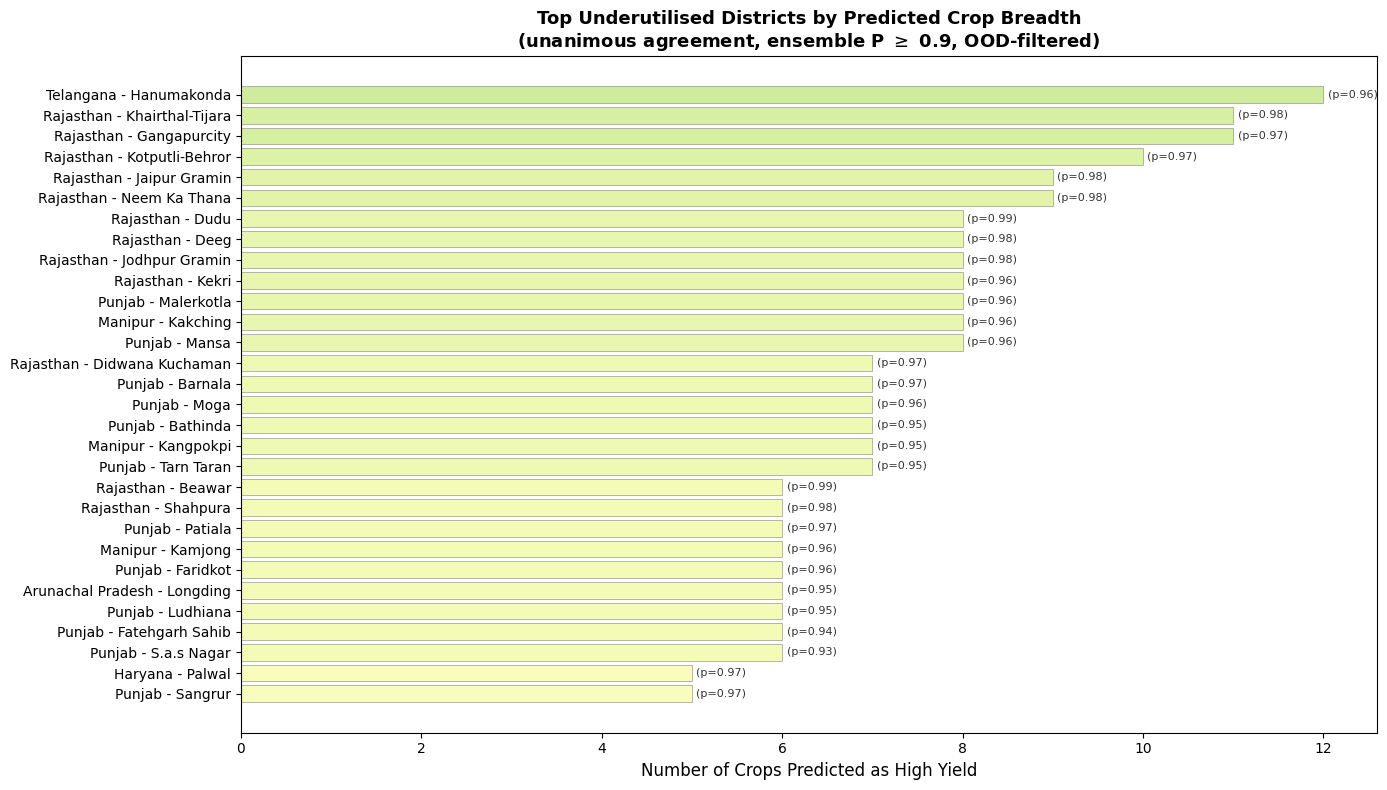

Saved → underutilised_districts/top_districts_crop_breadth.png


In [55]:
# Rebuild district summary from the strictly filtered high_df
strict_summary = (
    high_df
    .groupby(["state", "district", "location"])
    .agg(
        crops_high           = ("crop", "count"),
        mean_ensemble_proba  = ("ensemble_high_proba", "mean"),
        mean_ood_distance    = ("ood_distance", "mean"),
    )
    .reset_index()
    .sort_values(["crops_high", "mean_ensemble_proba"], ascending=False)
    .reset_index(drop=True)
)
strict_summary["pct_crops_high"] = (
    strict_summary["crops_high"] / len(trained_models) * 100
).round(1)

top_districts = strict_summary.head(30).copy()
top_districts["label"] = top_districts["state"] + " - " + top_districts["district"]

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(
    top_districts["label"],
    top_districts["crops_high"],
    color=plt.cm.YlGn(top_districts["pct_crops_high"] / 100),
    edgecolor="grey",
    linewidth=0.4,
)
ax.invert_yaxis()
ax.set_xlabel("Number of Crops Predicted as High Yield", fontsize=12)
ax.set_title(
    "Top Underutilised Districts by Predicted Crop Breadth\n"
    "(unanimous agreement, ensemble P $\\geq$ 0.9, OOD-filtered)",
    fontsize=13, fontweight="bold"
)

# Annotate with % and ensemble proba
for bar, (_, row) in zip(bars, top_districts.iterrows()):
    ax.text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"(p={row['mean_ensemble_proba']:.2f})",
        va="center", fontsize=8, color="#333333"
    )

plt.tight_layout()
plt.savefig("underutilised_districts/top_districts_crop_breadth.png", dpi=150)
plt.show()
print("Saved → underutilised_districts/top_districts_crop_breadth.png")

### 7b — Crop × District heatmap (ensemble probability for High)

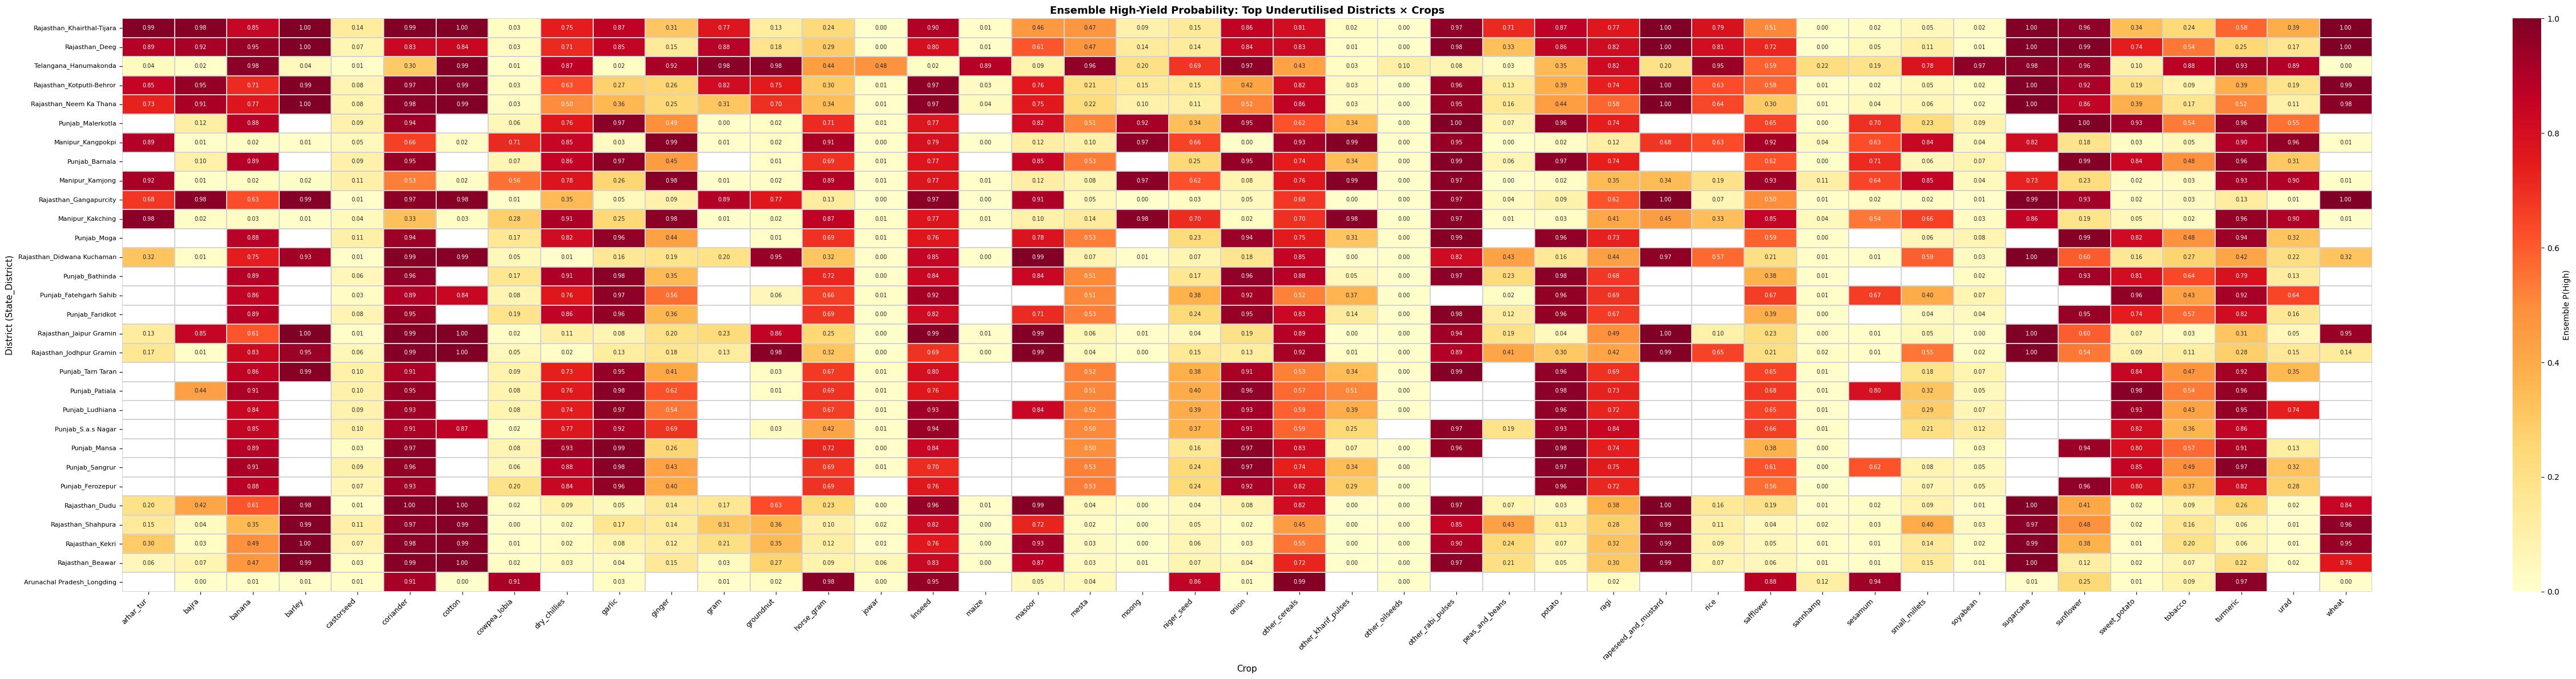

Saved → underutilised_districts/heatmap_district_crop.png


In [50]:
# Focus on the top-30 most promising districts and all crops
top30_locs = district_summary[district_summary["crops_high"] > 0].head(30)["location"].tolist()

heatmap_df = (
    results_df[results_df["location"].isin(top30_locs)]
    .pivot_table(index="location", columns="crop", values="ensemble_high_proba", aggfunc="mean")
)

# Sort rows by total high probability across crops
heatmap_df = heatmap_df.loc[
    heatmap_df.sum(axis=1).sort_values(ascending=False).index
]

fig, ax = plt.subplots(figsize=(max(12, len(heatmap_df.columns) * 1.2), max(10, len(heatmap_df) * 0.4)))
sns.heatmap(
    heatmap_df,
    cmap="YlOrRd",
    vmin=0, vmax=1,
    linewidths=0.3,
    linecolor="lightgrey",
    annot=True, fmt=".2f", annot_kws={"size": 7},
    cbar_kws={"label": "Ensemble P(High)"},
    ax=ax,
)
ax.set_title(
    "Ensemble High-Yield Probability: Top Underutilised Districts × Crops",
    fontsize=13, fontweight="bold"
)
ax.set_xlabel("Crop", fontsize=11)
ax.set_ylabel("District (State_District)", fontsize=11)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig("underutilised_districts/heatmap_district_crop.png", dpi=150)
plt.show()
print("Saved → underutilised_districts/heatmap_district_crop.png")

### 7c — Model agreement breakdown (votes = 1, 2, 3)

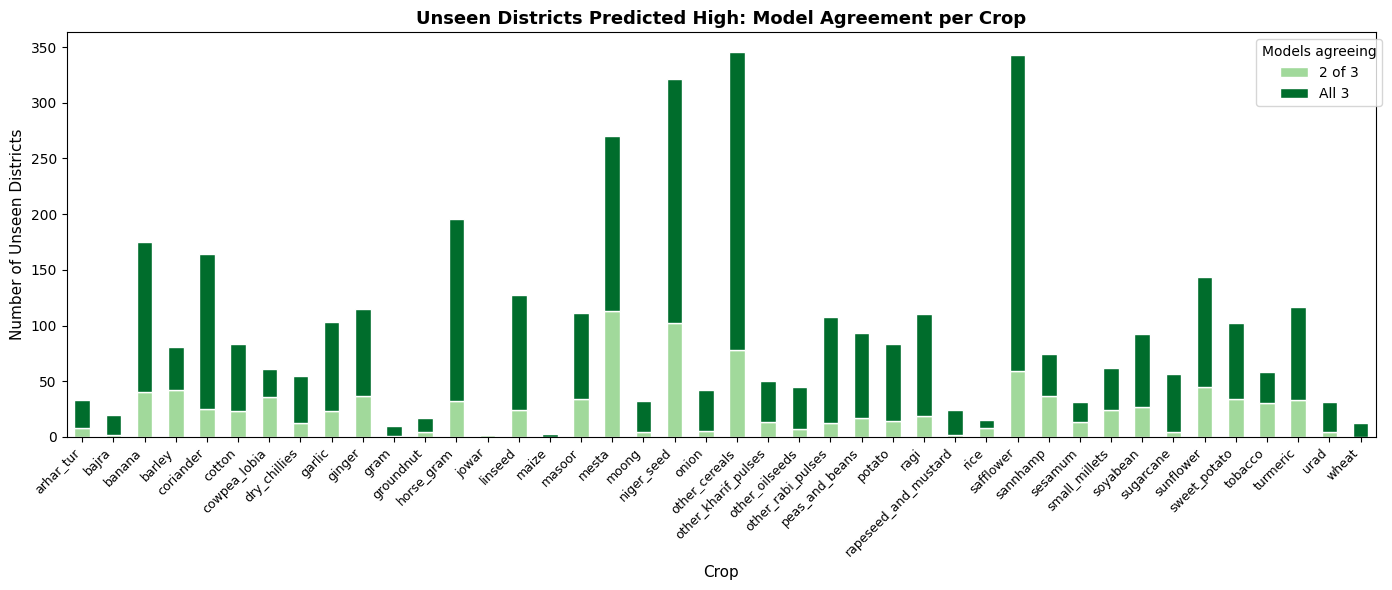

Saved → underutilised_districts/model_agreement_per_crop.png


In [59]:
# ================================
# Create plotting-only dataset
# ================================
plot_df = results_df[results_df["votes_for_high"] >= 2].copy()

# ================================
# Build vote counts per crop
# ================================
vote_counts = (
    plot_df
    .groupby(["votes_for_high", "crop"])
    .size()
    .reset_index(name="n")
    .pivot(index="crop", columns="votes_for_high", values="n")
    .fillna(0)
    .astype(int)
)

# Ensure both agreement levels exist (2-of-3 and 3-of-3)
vote_counts = vote_counts.reindex(columns=[2, 3], fill_value=0)

# ================================
# Plot
# ================================
ax = vote_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 6),
    color=["#a1d99b", "#006d2c"],  # light green = 2/3, dark green = 3/3
    edgecolor="white",
)

# ================================
# Titles and labels
# ================================
plt.title(
    "Unseen Districts Predicted High: Model Agreement per Crop",
    fontsize=13,
    fontweight="bold"
)
plt.xlabel("Crop", fontsize=11)
plt.ylabel("Number of Unseen Districts", fontsize=11)

# ================================
# Legend (fixed + explicit)
# ================================
ax.legend(
    ["2 of 3", "All 3"],
    title="Models agreeing",
    bbox_to_anchor=(1.01, 1)
)

# ================================
# Aesthetics
# ================================
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.tight_layout()

# ================================
# Save + show
# ================================
plt.savefig(
    "underutilised_districts/model_agreement_per_crop.png",
    dpi=150
)
plt.show()

print("Saved → underutilised_districts/model_agreement_per_crop.png")

### 7d — State-level rollup

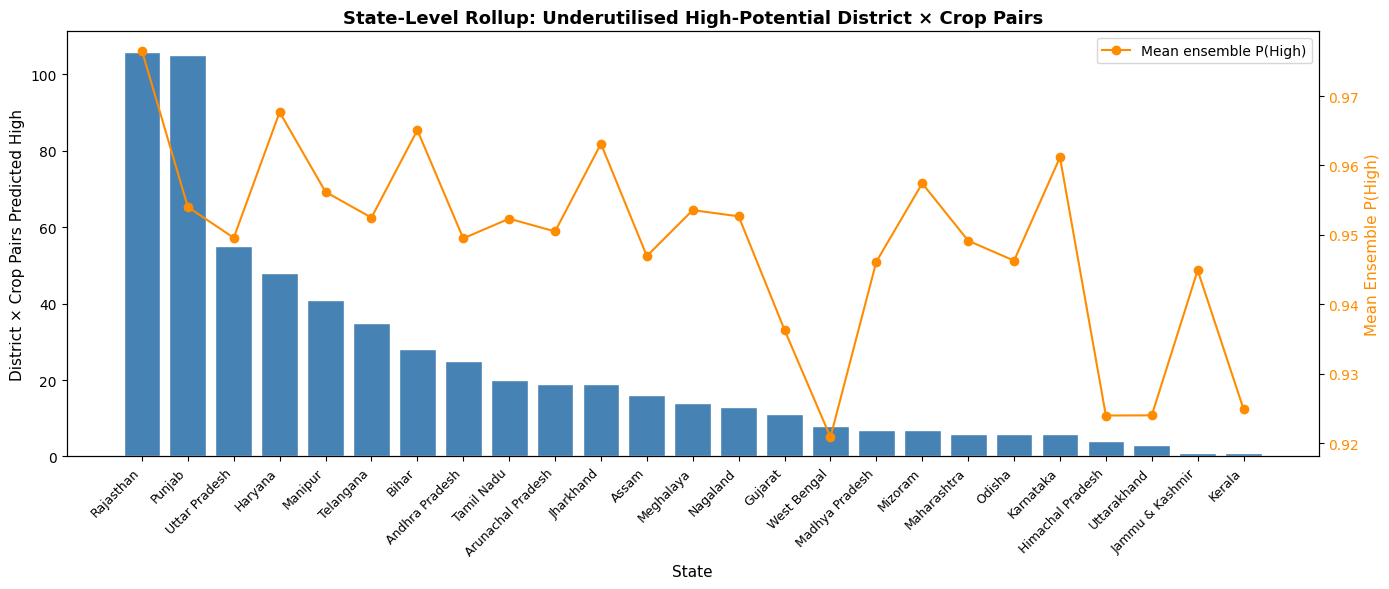

Saved → underutilised_districts/state_rollup.png


In [66]:
state_rollup = (
    high_df
    .groupby("state")
    .agg(
        high_district_crop_pairs = ("location", "count"),
        unique_districts         = ("district", "nunique"),
        unique_crops             = ("crop", "nunique"),
        mean_proba               = ("ensemble_high_proba", "mean"),
    )
    .sort_values("high_district_crop_pairs", ascending=False)
    .reset_index()
)

state_rollup.to_csv("underutilised_districts/state_rollup.csv", index=False)

# =========================
# Plot
# =========================
fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(
    state_rollup["state"],
    state_rollup["high_district_crop_pairs"],
    color="steelblue",
    edgecolor="white"
)

ax2 = ax.twinx()

ax2.plot(
    state_rollup["state"],
    state_rollup["mean_proba"],
    color="darkorange",
    marker="o",
    linewidth=1.5,
    label="Mean ensemble P(High)"
)

# =========================
# Labels
# =========================
ax.set_xlabel("State", fontsize=11)
ax.set_ylabel("District × Crop Pairs Predicted High", fontsize=11)
ax2.set_ylabel("Mean Ensemble P(High)", fontsize=11, color="darkorange")
ax2.tick_params(axis="y", labelcolor="darkorange")

ax.set_title(
    "State-Level Rollup: Underutilised High-Potential District × Crop Pairs",
    fontsize=13,
    fontweight="bold"
)

# =========================
# FIX: Proper tick handling (this is the key fix)
# =========================
ax.set_xticks(range(len(state_rollup["state"])))
ax.set_xticklabels(
    state_rollup["state"],
    rotation=45,
    ha="right",
    fontsize=9
)

# spacing so labels don’t collide
plt.subplots_adjust(bottom=0.25)

# legend for line
ax2.legend(loc="upper right")

# =========================
# Save + show
# =========================
plt.tight_layout()
plt.savefig("underutilised_districts/state_rollup.png", dpi=150)
plt.show()

print("Saved → underutilised_districts/state_rollup.png")

## 8 — Policy Narrative Report

Generates a plain-text report that can be handed directly to policymakers.

In [53]:
report_lines = []
sep = "=" * 70

report_lines.append(sep)
report_lines.append("UNDERUTILISED DISTRICTS — POLICY REPORT")
report_lines.append("Identifying districts with no crop data but high model-predicted yield potential")
report_lines.append(sep)
report_lines.append("")

report_lines.append("METHODOLOGY")
report_lines.append("-" * 40)
report_lines.append(
    f"  Three models were trained per crop on existing district data (KNN, Random Forest, XGBoost).\n"
    f"  Each model predicts the yield class for districts that have climate data but NO historical\n"
    f"  crop records. A district × crop pair is flagged as 'High Potential' when at least\n"
    f"  {MAJORITY_VOTE} out of 3 models predict the '{HIGH_CLASS}' yield class.\n"
    f"  The ensemble probability is the average of all three models' P(High)."
)
report_lines.append("")

report_lines.append("SUMMARY STATISTICS")
report_lines.append("-" * 40)
report_lines.append(f"  Crops analysed                    : {len(trained_models)}")
report_lines.append(f"  Total unseen district-crop pairs  : {len(results_df):,}")
report_lines.append(f"  High-potential pairs (majority)   : {results_df['majority_high'].sum():,}")
report_lines.append(f"  Unique high-potential districts   : {high_df['location'].nunique():,}")
report_lines.append("")

report_lines.append(f"TOP {TOP_N_REPORT} DISTRICTS (by breadth — number of crops predicted High)")
report_lines.append("-" * 40)
top_n = district_summary[district_summary["crops_high"] > 0].head(TOP_N_REPORT)
report_lines.append(
    f"  {'Rank':<5} {'State':<20} {'District':<25} {'Crops High':>10} {'% of Evaluated':>15} {'Mean P(High)':>12}"
)
for rank, (_, row) in enumerate(top_n.iterrows(), 1):
    report_lines.append(
        f"  {rank:<5} {row['state']:<20} {row['district']:<25} "
        f"{int(row['crops_high']):>10} {row['pct_crops_high']:>14.1f}% {row['mean_ensemble_proba']:>12.3f}"
    )
report_lines.append("")

report_lines.append("PER-CROP HIGH-POTENTIAL DISTRICT COUNT")
report_lines.append("-" * 40)
crop_counts = (
    high_df.groupby("crop")
    .agg(n_high=("location", "count"), mean_proba=("ensemble_high_proba", "mean"))
    .sort_values("n_high", ascending=False)
)
for crop, row in crop_counts.iterrows():
    report_lines.append(f"  {crop:<35}  {int(row['n_high']):>4} districts  (mean P={row['mean_proba']:.3f})")
report_lines.append("")

report_lines.append("POLICY RECOMMENDATIONS")
report_lines.append("-" * 40)
report_lines.append(
    "  1. PRIORITY SOIL SURVEYS: Dispatch agronomy teams to the top-ranked districts\n"
    "     to verify climate-model assumptions with ground-truth soil and irrigation audits.\n"
    "\n"
    "  2. PILOT PROGRAMMES: Launch small-scale cultivation trials in the top 10 districts\n"
    "     for the crop(s) with highest ensemble P(High), using local farmer cooperatives.\n"
    "\n"
    "  3. DATA COLLECTION IMPERATIVE: All flagged districts currently lack official crop\n"
    "     yield records. Establishing monitoring points here will close the data gap and\n"
    "     allow future model retraining with observed outcomes.\n"
    "\n"
    "  4. INFRASTRUCTURE ALIGNMENT: Cross-reference high-potential districts with existing\n"
    "     irrigation, road, and market-access databases to prioritise those where investment\n"
    "     marginal cost is lowest.\n"
    "\n"
    "  5. CAVEATS: Model predictions are based on climate features alone. Soil quality,\n"
    "     water availability, socio-economic conditions, and local agronomic expertise\n"
    "     must be considered before any policy commitment."
)
report_lines.append("")
report_lines.append(sep)

report_text = "\n".join(report_lines)
report_path = "underutilised_districts/policy_report.txt"
with open(report_path, "w") as f:
    f.write(report_text)

print(report_text)
print(f"\nReport saved → {report_path}")

UNDERUTILISED DISTRICTS — POLICY REPORT
Identifying districts with no crop data but high model-predicted yield potential

METHODOLOGY
----------------------------------------
  Three models were trained per crop on existing district data (KNN, Random Forest, XGBoost).
  Each model predicts the yield class for districts that have climate data but NO historical
  crop records. A district × crop pair is flagged as 'High Potential' when at least
  2 out of 3 models predict the 'High' yield class.
  The ensemble probability is the average of all three models' P(High).

SUMMARY STATISTICS
----------------------------------------
  Crops analysed                    : 43
  Total unseen district-crop pairs  : 11,907
  High-potential pairs (majority)   : 604
  Unique high-potential districts   : 244

TOP 30 DISTRICTS (by breadth — number of crops predicted High)
----------------------------------------
  Rank  State                District                  Crops High  % of Evaluated Mean P(High)

## 9 — Output File Summary

| File | Description |
|---|---|
| **`per_model_high_predictions.csv`** | **Primary review table — one row per (district, crop, model) where that model predicted High, with CV accuracy and F1 for that model × crop joined in** |
| `all_unseen_predictions.csv` | Every (district, crop) pair with all three model predictions and ensemble stats |
| `district_level_summary.csv` | One row per district: how many crops scored majority-High |
| `state_rollup.csv` | State-level aggregation |
| `top_districts_crop_breadth.png` | Bar chart: breadth of majority-High predictions per district |
| `heatmap_district_crop.png` | Ensemble probability heatmap: district × crop |
| `model_agreement_per_crop.png` | Stacked bar: model agreement breakdown per crop |
| `state_rollup.png` | State-level bar + line chart |
| `policy_report.txt` | Human-readable policy narrative |

**Suggested workflow for policy decisions:**
1. Open `per_model_high_predictions.csv` and filter to districts you're interested in.
2. For each (district, crop) row, check `cv_f1_mean` — if the model that predicted High has poor CV performance on that crop, downweight it.
3. `votes_for_high` tells you how many models agree. Unanimous (3) + high `cv_f1_mean` across all three = strong signal. Single model + low F1 = weak signal, investigate further.
4. Use `district_level_summary.csv` to find districts that score well across multiple crops — these are the most versatile candidates for intervention.